# Geopolitical Shocks and Energy Volatility
# A Time Series Analysis of Brent Crude Oil Prices (2000–2024)
# TSAC Individual Project — ENSIA 2024/2025
# Author: Mehdi BOUZOUL

---

# Abstract

Brent crude prices are critical to the fiscal stability of oil-exporting nations like Algeria. This project analyzes weekly Brent log-returns from FRED (series DCOILBRENTEU) from 2000 to 2024 ($n \approx 1,305$). Following the ARIMA modeling pipeline—including stationarity testing and ACF/PACF analysis — we identified and validated candidate models to produce 2025 forecasts. A contextual case study compares these predictions to actual 2025–2026 prices, quantifying the "war premium" caused by geopolitical tensions in the Strait of Hormuz. The results highlight the limitations of univariate models in anticipating structural breaks, a finding of high relevance to Algeria’s hydrocarbon-dependent budget.

---

# Introduction

Crude oil is the world's most traded commodity and the primary driver of the global energy system. For Algeria, a member of OPEC, Brent crude prices are a matter of national security. Hydrocarbons account for approximately 60% of government revenue and 90% of export earnings via the state company, Sonatrach. Consequently, price fluctuations—such as the 2020 COVID-19 shock—directly impact the national trade balance and trade surplus.

This project applies the Box-Jenkins ARIMA methodology to weekly Brent prices to identify the statistical structure of price changes. The objective is to build a predictive model while identifying its inherent deficiencies. Specifically, we examine the model's inability to forecast exogenous shocks, such as the 2026 escalation in the Strait of Hormuz, using the post-2024 period as an out-of-sample test for geopolitical risk.

**Data source:** Federal Reserve Bank of St. Louis — FRED Economic Data, series
`DCOILBRENTEU` (Crude Oil Prices: Brent — Europe), available at
`https://fred.stlouisfed.org/series/DCOILBRENTEU`. Weekly frequency, USD per barrel.

---

# Packages and Data

## Required packages

In [ ]:
install.packages(c("quantmod","TSA","astsa","forecast","tseries","FinTS","lmtest","ggplot2")) # this will take about 1 minute

library(quantmod)   # FRED data download
library(TSA)        # armasubsets, runs(), season()
library(astsa)      # acf2(), sarima()
library(forecast)   # Arima(), auto.arima(), forecast()
library(tseries)    # adf.test(), kpss.test()
library(FinTS)      # ArchTest() — ARCH effects test
library(lmtest)     # coeftest()
library(ggplot2)    # optional enhanced plots

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Downloading data from FRED

**what is a time series?**
A time series $\{Y_t, t = 1, 2, \ldots, n\}$ is a sequence of observations made
sequentially in time. Here $Y_t$ is the weekly Brent crude oil price (USD/barrel).
The key modelling question is whether $\{Y_t\}$ is **stationary** — meaning its
statistical properties (mean, variance, autocovariance) do not change over time.
We will see that raw prices are non-stationary, but *log-returns* are approximately
stationary.

In [ ]:
# Download directly from FRED (requires internet connection in Colab/RStudio)
getSymbols("DCOILBRENTEU",
           src  = "FRED",
           from = "2000-01-01",
           to   = "2024-12-31",
           auto.assign = TRUE)

# Convert to weekly series (FRED gives daily; we take weekly means)
brent_daily  <- DCOILBRENTEU
brent_weekly <- apply.weekly(brent_daily, mean, na.rm = TRUE)

# Remove any remaining NA rows (e.g. holiday weeks)
brent_weekly <- na.omit(brent_weekly)

# Convert to plain ts object for compatibility with TSA/astsa
brent_ts <- ts(as.numeric(brent_weekly),
               start     = c(2000, 1),
               frequency = 52)   # 52 weeks per year

cat("=== Dataset summary ===\n")
cat("Period : 2000-W01 to 2024-W52\n")
cat("Obs    :", length(brent_ts), "weekly observations\n")
cat("Min    :", round(min(brent_ts),  2), "USD/barrel\n")
cat("Max    :", round(max(brent_ts),  2), "USD/barrel\n")
cat("Mean   :", round(mean(brent_ts), 2), "USD/barrel\n")

[1] "DCOILBRENTEU"

NOTE: `apply.weekly(..., FUN = mean)` operates by column, unlike other math
  functions (e.g. median, sum, var, sd). Please use `FUN = colMeans` instead,
  and use `FUN = function(x) mean(x)` to take the mean of all columns. Set
  `options(xts.message.period.apply.mean = FALSE)` to suppress this message.



=== Dataset summary ===
Period : 2000-W01 to 2024-W52
Obs    : 1305 weekly observations
Min    : 14.24 USD/barrel
Max    : 141.06 USD/barrel
Mean   : 66.71 USD/barrel


---

# Step 1 — Exploratory Analysis

Exploratory analysis answers four questions before touching any model:

1. **Trend** — Is the mean level $\mu_t$ changing over time? (violates stationarity)
2. **Seasonality** — Is there a regular within-year cycle?
3. **Variance** — Is $\text{Var}(Y_t)$ constant, or does it grow with the mean?
4. **Structural breaks** — Did the series change behaviour at identifiable dates?

A stationary process requires constant mean and constant autocovariance.
## Raw price plot

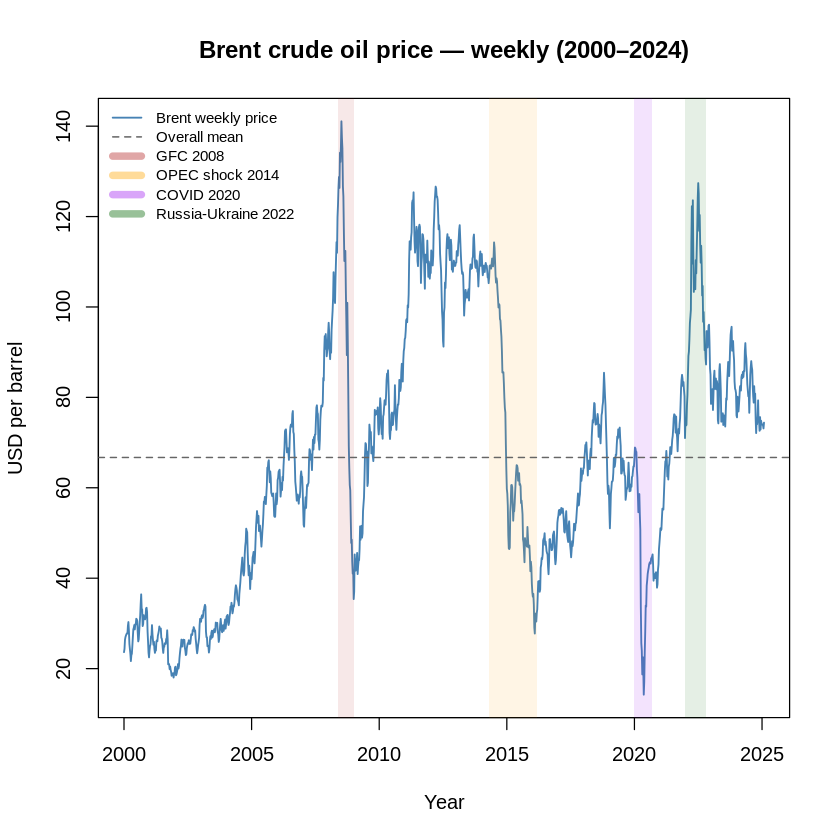

In [ ]:
# Define major geopolitical events for annotation
events <- data.frame(
  year  = c(2008.6, 2014.5, 2020.2, 2022.2),
  label = c("GFC\n2008", "OPEC\nshock\n2014", "COVID\n2020", "Russia-\nUkraine\n2022"),
  price = c(140, 50, 20, 128)
)

plot(brent_ts,
     ylab = "USD per barrel",
     xlab = "Year",
     main = "Brent crude oil price — weekly (2000–2024)",
     type = "l",
     col  = "steelblue",
     lwd  = 1.5)

# Shade recessions / major shocks
rect(2008.4, par("usr")[3], 2009.0, par("usr")[4],
     col = adjustcolor("firebrick", 0.10), border = NA)
rect(2014.3, par("usr")[3], 2016.2, par("usr")[4],
     col = adjustcolor("orange",    0.10), border = NA)
rect(2020.0, par("usr")[3], 2020.7, par("usr")[4],
     col = adjustcolor("purple",    0.12), border = NA)
rect(2022.0, par("usr")[3], 2022.8, par("usr")[4],
     col = adjustcolor("darkgreen", 0.10), border = NA)

abline(h = mean(brent_ts), lty = 2, col = "gray40", lwd = 1.2)

legend("topleft",
       legend = c("Brent weekly price", "Overall mean",
                  "GFC 2008", "OPEC shock 2014",
                  "COVID 2020", "Russia-Ukraine 2022"),
       col    = c("steelblue", "gray40",
                  adjustcolor("firebrick",0.4), adjustcolor("orange",0.4),
                  adjustcolor("purple",0.4),    adjustcolor("darkgreen",0.4)),
       lty    = c(1, 2, 1, 1, 1, 1),
       lwd    = c(1.5, 1.2, 6, 6, 6, 6),
       bty    = "n", cex = 0.75)

**Interpretation:**
The raw price series exhibits at least four major structural breaks corresponding to
identifiable events: the Global Financial Crisis of 2008 (peak ~$145, collapse to ~$35),
the OPEC supply shock of 2014–2016 (sustained price drop from ~$110 to ~$28), the
COVID-19 demand collapse of March 2020 (historic low of ~$9), and the Russia-Ukraine war
price spike of 2022 (~$128). The mean clearly is not constant — the series is
**strongly non-stationary** in both mean and variance. The variance itself appears to
grow with the price level, suggesting a log transformation is appropriate.

## Log transformation to stabilise variance

When the variance of a series grows proportionally with its mean, the
natural logarithm $\log(Y_t)$ stabilises the variance -special case of Box-Cox transformation with
$\lambda$ = 0. This is a standard preliminary transformation for financial price series.

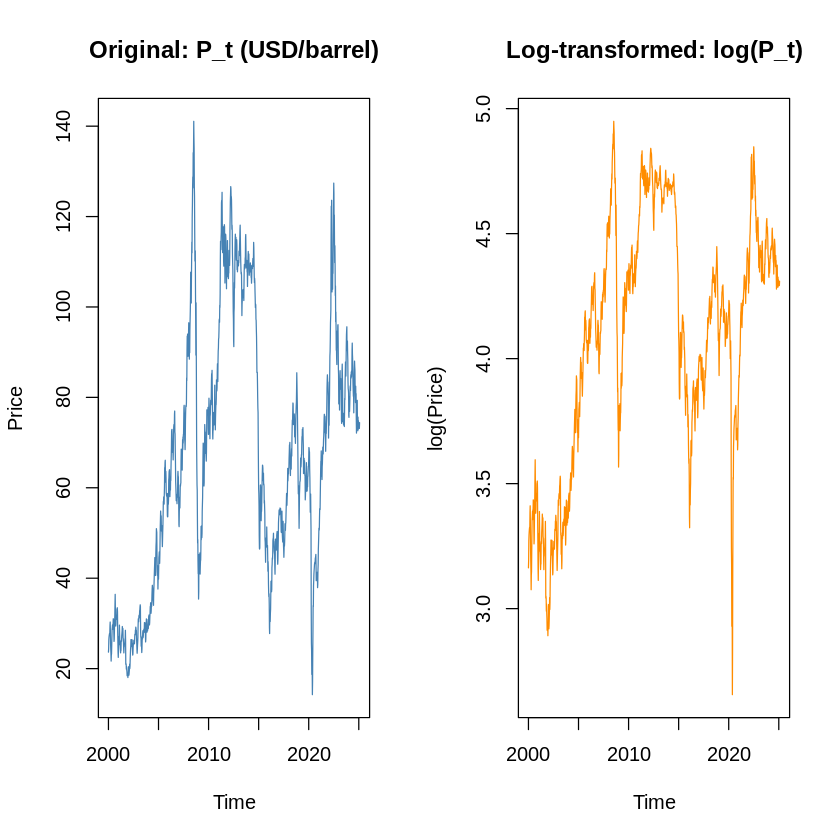

In [ ]:
log_brent <- log(brent_ts)

par(mfrow = c(1, 2))
plot(brent_ts,  main = "Original: P_t (USD/barrel)", type = "l",
     col = "steelblue", ylab = "Price")
plot(log_brent, main = "Log-transformed: log(P_t)",  type = "l",
     col = "darkorange", ylab = "log(Price)")
par(mfrow = c(1, 1))

**Interpretation:**
The log-transformed series still shows a clear trend (non-constant mean) but the
amplitude of fluctuations is now much more uniform across the full sample period -comparing to old one.
The log transformation partially addresses the variance issue but does not make the
series stationary — further transformation is needed.

## Moving average trend smoother
A moving average filter $V_t = \frac{1}{m}\sum_{j=0}^{m-1}Y_{t-j}$
reveals the underlying long-run trend by smoothing short-term noise.

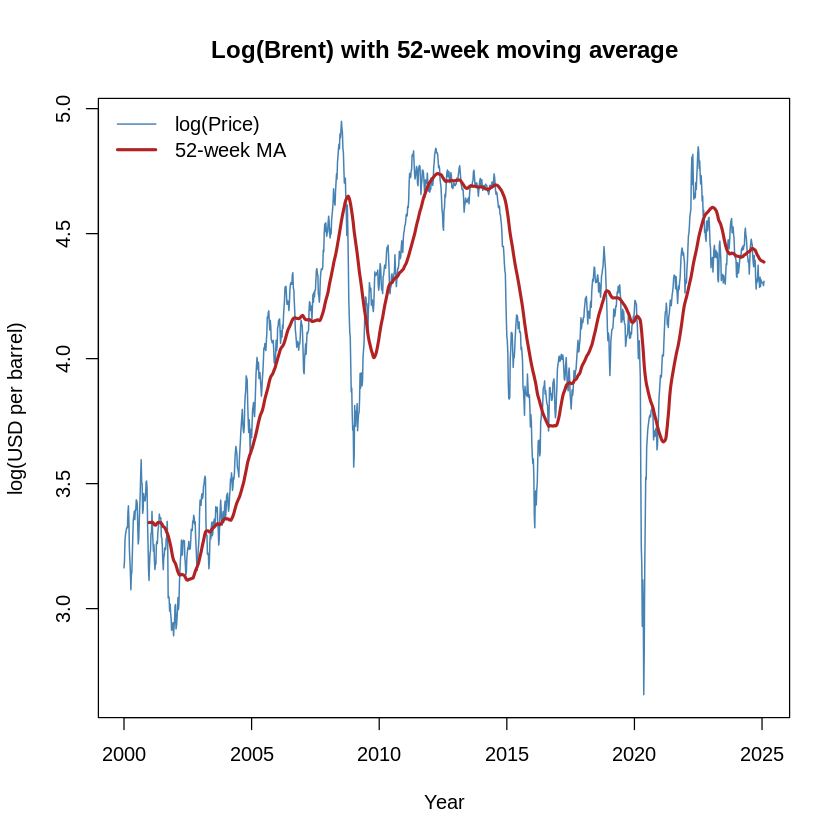

In [ ]:
ma52 <- stats::filter(log_brent, rep(1/52, 52), sides = 1)

plot(log_brent,
     main = "Log(Brent) with 52-week moving average",
     type = "l", col = "steelblue", lwd = 1.2,
     ylab = "log(USD per barrel)", xlab = "Year")
lines(ma52, col = "firebrick", lwd = 2.5, lty = 1)
legend("topleft",
       legend = c("log(Price)", "52-week MA"),
       col    = c("steelblue", "firebrick"),
       lty    = 1, lwd = c(1.2, 2.5), bty = "n")

**Interpretation:**
The 52-week MA confirms the visual impression: there is no simple monotone trend —
the series has multiple regimes separated by geopolitical and economic shocks. This
non-trivial trend structure reinforces that we must difference rather than simply
detrend by regression.

---

# Step 2 — Stationarity Assessment and the Choice of Y_t

## why we model log-returns, not prices

The raw price $P_t$ is clearly non-stationary. We have two options:

**Option A — Detrend by regression** : fit $\log P_t = \beta_0 + \beta_1 t + e_t$ and model the residuals. This works if the trend is deterministic, but oil prices have a *stochastic* trend (random walk with drift), so regression detrending leaves autocorrelated residuals.

**Option B — First-difference the log** : define
$$r_t = \log P_t - \log P_{t-1} = \log\!\left(\frac{P_t}{P_{t-1}}\right)$$
This is the **weekly log-return**. It is approximately the percentage weekly price change.
Taking the first difference of the log is equivalent to setting $d = 1$ in ARIMA on the
log scale, which removes a stochastic linear trend. This is the standard approach for
financial price series -same concept is applied on oil and gas prices.

Our working series is therefore $Y_t = r_t$ — the weekly log-return.

Working series: weekly log-returns
Length  : 1304 observations
Mean    : 0.00088 
Std dev : 0.0472 
Min     : -0.4078 
Max     : 0.3242 


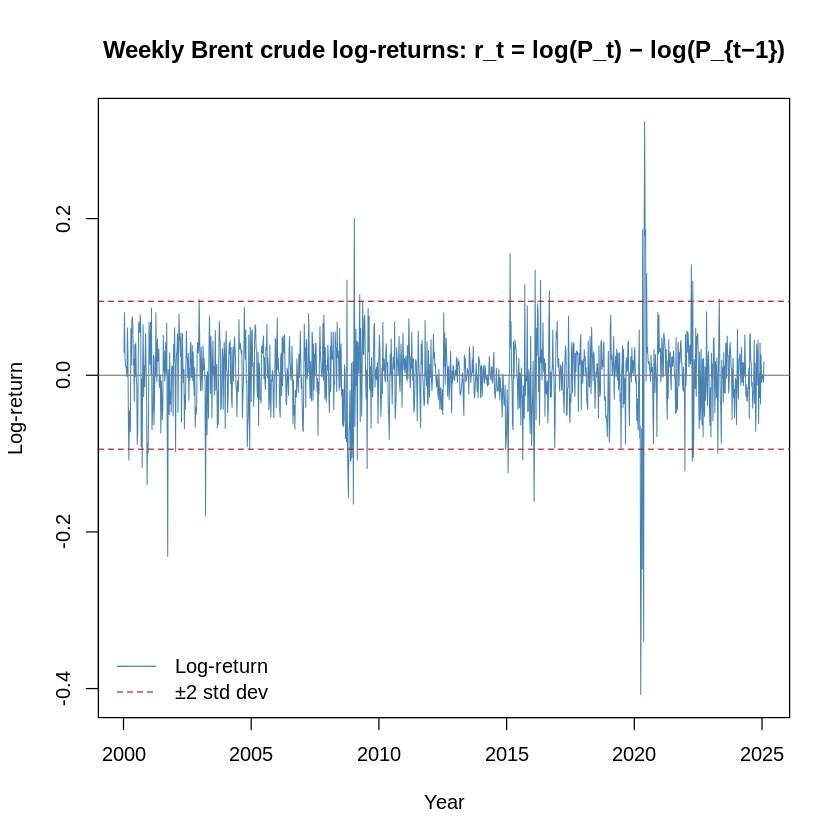

In [ ]:
log_returns <- diff(log_brent)
log_returns <- na.omit(log_returns)

cat("Working series: weekly log-returns\n")
cat("Length  :", length(log_returns), "observations\n")
cat("Mean    :", round(mean(log_returns),   5), "\n")
cat("Std dev :", round(sd(log_returns),     4), "\n")
cat("Min     :", round(min(log_returns),    4), "\n")
cat("Max     :", round(max(log_returns),    4), "\n")

plot(log_returns,
     main = "Weekly Brent crude log-returns: r_t = log(P_t) − log(P_{t−1})",
     type = "l", col = "steelblue", lwd = 0.8,
     ylab = "Log-return", xlab = "Year")
abline(h = 0,            lty = 1, col = "gray50")
abline(h =  2*sd(log_returns), lty = 2, col = "firebrick")
abline(h = -2*sd(log_returns), lty = 2, col = "firebrick")
legend("bottomleft",
       legend = c("Log-return", "±2 std dev"),
       col    = c("steelblue", "firebrick"),
       lty    = c(1, 2), bty = "n")

**Interpretation:**
The weekly log-returns oscillate around zero with no visible trend, confirming stationarity of $r_t$.
Roughly 95% of observations fall within the ±2σ bands (red dashed lines), as expected for a near-stationary process. The exceptions are all linked to identifiable geopolitical or macroeconomic shocks — consistent with the view that normal market dynamics follow ARIMA structure, while extreme moves require explanation:
**2008–2009 (Global Financial Crisis)**: sharp negative spike as demand collapsed
**2020 (COVID-19)**: the largest outlier in the entire sample (~−0.40), reflecting the **historic** demand destruction of March 2020.
**2022 (Russia-Ukraine war)**: cluster of spikes above the +2σ band

## Formal stationarity tests

In [ ]:
cat("╔══════════════════════════════════════════════════╗\n")
cat("║        STATIONARITY TESTS ON LOG-RETURNS         ║\n")
cat("╚══════════════════════════════════════════════════╝\n\n")

cat("── Augmented Dickey-Fuller (ADF) test (H₀: unit root = non-stationary) ──\n")
adf_result <- adf.test(as.numeric(log_returns), alternative = "stationary")
print(adf_result)

cat("\n── KPSS test (H₀: stationary) ──\n")
kpss_result <- kpss.test(as.numeric(log_returns), null = "Level")
print(kpss_result)

╔══════════════════════════════════════════════════╗
║        STATIONARITY TESTS ON LOG-RETURNS         ║
╚══════════════════════════════════════════════════╝

── Augmented Dickey-Fuller (ADF) test (H₀: unit root = non-stationary) ──


Warning message in adf.test(as.numeric(log_returns), alternative = "stationary"):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  as.numeric(log_returns)
Dickey-Fuller = -11.136, Lag order = 10, p-value = 0.01
alternative hypothesis: stationary


── KPSS test (H₀: stationary) ──


Warning message in kpss.test(as.numeric(log_returns), null = "Level"):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  as.numeric(log_returns)
KPSS Level = 0.065954, Truncation lag parameter = 7, p-value = 0.1



**Interpretation:**
The ADF test should strongly reject the null of a unit root (p-value < 0.01), meaning
the log-return series is stationary. The KPSS test should fail to reject stationarity
(p-value = 0.1 > 0.05). Both tests in agreement confirm that $d = 1$ applied to $\log P_t$
produces a stationary series.
---

# Step 3 — Model Specification

## ACF and PACF interpretation rules

For a stationary ARMA(p, q) process:

| ACF                     | PACF                    | Candidate model |
|-------------------------|-------------------------|-----------------|
| Cuts off after lag $q$  | Tails off geometrically | MA($q$)         |
| Tails off geometrically | Cuts off after lag $p$  | AR($p$)         |
| Both tail off           | Both tail off           | ARMA($p$, $q$)  |
| All near zero           | All near zero           | White noise     |

The **95% significance bands** are at $\pm 1.96/\sqrt{n}$. Spikes outside these bands
indicate significant autocorrelation at that lag.

## ACF and PACF of the log-returns

ACF,0.24,0.05,0.1,-0.04,0.05,0.02,-0.09,-0.02,-0.08,-0.02,⋯,-0.02,0.04,0.03,0.01,-0.02,-0.04,-0.02,0.01,-0.02,0.01
PACF,0.24,-0.01,0.1,-0.10,0.09,-0.03,-0.08,0.01,-0.07,0.04,⋯,0.00,0.04,0.00,0.01,-0.06,-0.01,-0.01,0.01,-0.02,0.03


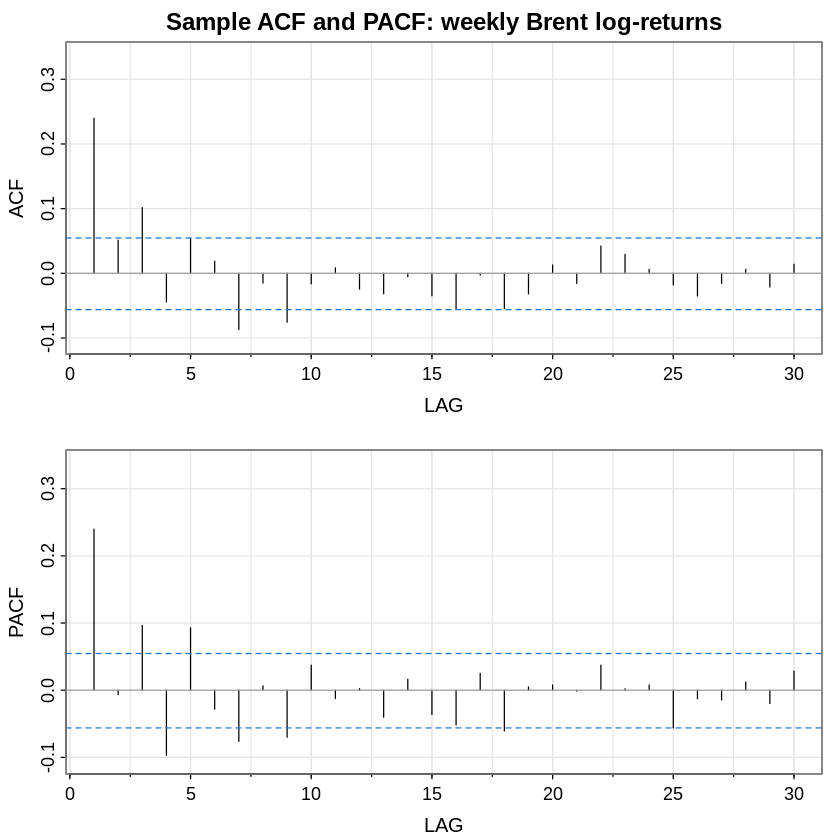

In [ ]:
# acf2 from astsa plots both together with 95% bands
acf2(as.numeric(log_returns),
     max.lag = 30,
     main    = "Sample ACF and PACF: weekly Brent log-returns")

**Interpretation:**
Both the ACF and PACF show a dominant significant spike at lag 1 (≈ 0.27), well beyond the 95% confidence bands. While there are minor secondary spikes (notably lag 3 in the ACF and lags 4–5 in the PACF), the primary structure is concentrated at the first lag.
The simultaneous significant spikes in both functions at lag 1 suggest that both AR and MA components are likely present, making a low-order ARMA(1,1) on log-returns (equivalent to an ARIMA(1,1,1) on prices) a strong candidate model. The positive autocorrelation at lag 1 indicates good short-term momentum: a price increase this week is modestly predictive of an increase next week.

**Note on heteroskedasticity:** We may notice that the variance of log-returns is not
constant — it is higher during crises (2008, 2020). This is called **volatility
clustering** or ARCH effects. ARIMA models the *conditional mean* structure, not the
variance. We will test for ARCH effects in the diagnostics section (Step 4) and
acknowledge this limitation in the Discussion (Step 6).


## Candidate models

Based on the ACF/PACF plots.

| Model   | ARIMA order      | Rationale |
|---------|------------------|-----------|
| Model A | ARIMA(0, 1, 1)   | ACF has dominant spike at lag 1, drops to near zero after — MA(1)  |
| Model B | ARIMA(1, 1, 1)   | Both ACF and PACF spike equally at lag 1 — neither cuts off cleanly|
| Model C | ARIMA(0, 1, 3)   | Marginally significant spikes at lags 1 and 3 in ACF               |
---

# Step 4 — Model Fitting and Diagnostics

## what good residuals look like

After fitting an ARIMA(p, d, q) model, the standardised residuals $\hat{e}_t / \hat{\sigma}_e$
should behave like an **iid white noise process** :

1. **Time plot** — no visible pattern, no trend, no outlier clusters
2. **ACF of residuals** — all spikes within $\pm 1.96/\sqrt{n}$ (no remaining autocorrelation)
3. **Normal QQ plot** — residuals follow the diagonal line (Gaussian)
4. **Ljung-Box p-values** — all p > 0.05 (fail to reject H₀: residuals are white noise)
5. **Histogram** — approximately bell-shaped, possibly fat-tailed for financial data

The `sarima()` function from the `astsa` package produces all five panels automatically.

## Fit and diagnose all candidate models

══════════════════════════════
 Model A: ARIMA(0, 1, 1)     
══════════════════════════════
initial  value -3.053777 
iter   2 value -3.083703
iter   3 value -3.083770
iter   3 value -3.083770
iter   3 value -3.083770
final  value -3.083770 
converged
initial  value -3.083746 
iter   1 value -3.083746
final  value -3.083746 
converged
<><><><><><><><><><><><><><>
 
Coefficients: 
         Estimate     SE t.value p.value
ma1        0.2514 0.0283  8.8923  0.0000
constant   0.0009 0.0016  0.5548  0.5792

sigma^2 estimated as 0.002096383 on 1302 degrees of freedom 
 
AIC = -3.325013  AICc = -3.325006  BIC = -3.313112 
 
AIC: -4335.817  | BIC: -4320.298 


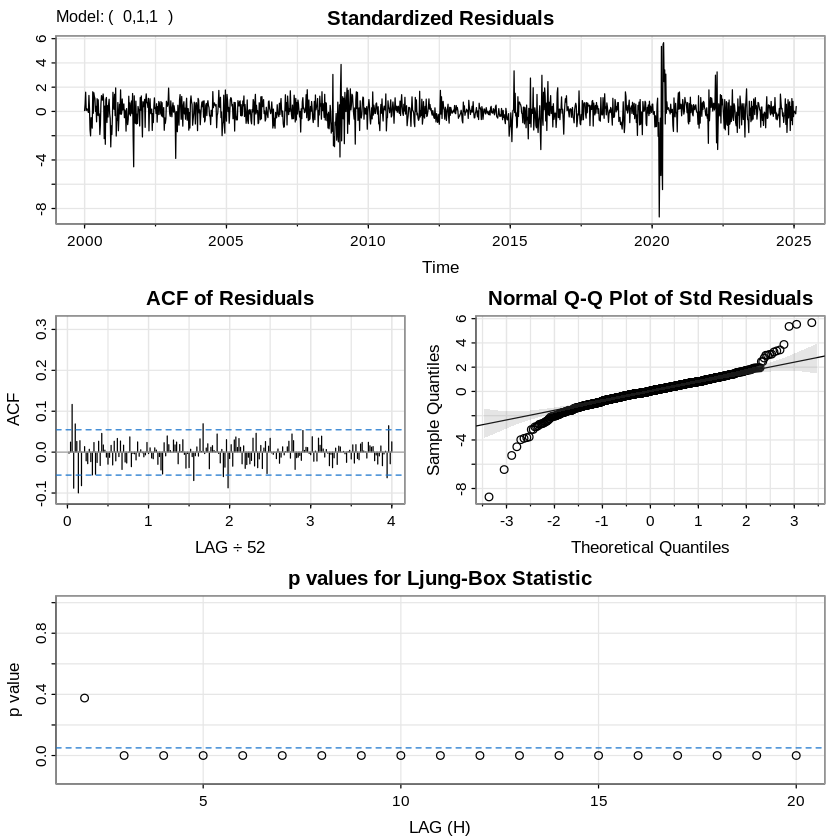

In [ ]:
cat("══════════════════════════════\n")
cat(" Model A: ARIMA(0, 1, 1)     \n")
cat("══════════════════════════════\n")
# sarima() fits on the LOG PRICE and sets d=1 internally
fit_A <- sarima(log_brent, p = 0, d = 1, q = 1)
# Correctly access AIC and BIC from the fitted model object
cat("AIC:", round(AIC(fit_A$fit), 4), " | BIC:", round(BIC(fit_A$fit), 4), "\n")

══════════════════════════════
 Model B: ARIMA(1, 1, 1)     
══════════════════════════════
initial  value -3.053532 
iter   2 value -3.057479
iter   3 value -3.083183
iter   4 value -3.083199
iter   5 value -3.083199
iter   6 value -3.083199
iter   7 value -3.083200
iter   8 value -3.083203
iter   9 value -3.083203
iter  10 value -3.083206
iter  11 value -3.083206
iter  12 value -3.083215
iter  13 value -3.083252
iter  14 value -3.083257
iter  15 value -3.083297
iter  16 value -3.083299
iter  17 value -3.083366
iter  18 value -3.083407
iter  19 value -3.083458
iter  20 value -3.083517
iter  21 value -3.083568
iter  22 value -3.084106
iter  23 value -3.084123
iter  24 value -3.084144
iter  25 value -3.084224
iter  26 value -3.084300
iter  27 value -3.084345
iter  28 value -3.084350
iter  29 value -3.084354
iter  30 value -3.084355
iter  31 value -3.084360
iter  32 value -3.084362
iter  33 value -3.084363
iter  34 value -3.084363
iter  34 value -3.084363
final  value -3.084363 
converge

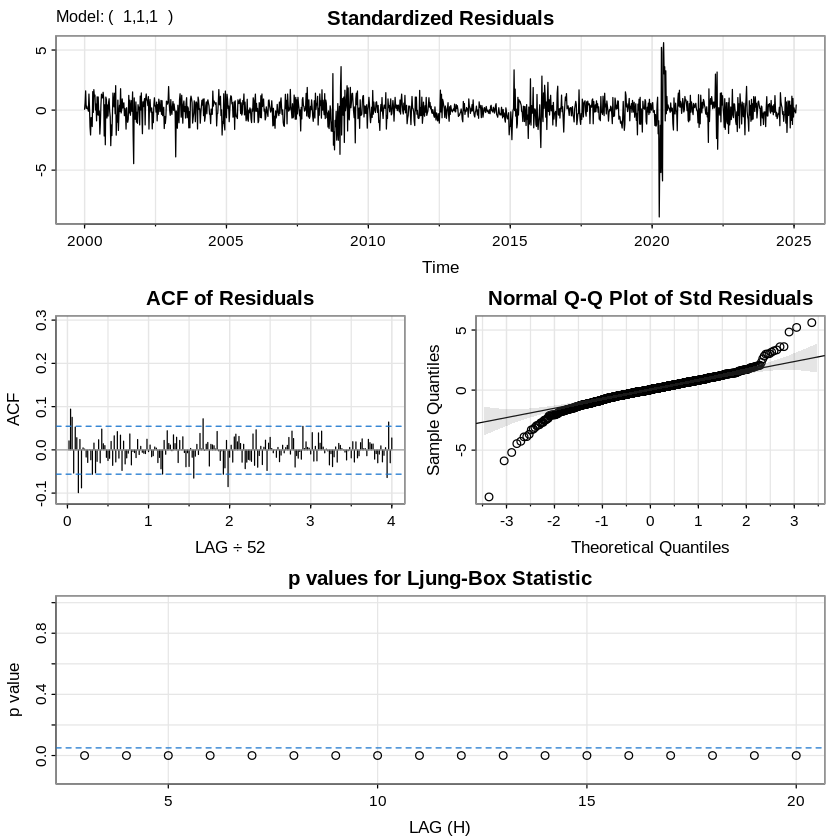

In [ ]:
cat("══════════════════════════════\n")
cat(" Model B: ARIMA(1, 1, 1)     \n")
cat("══════════════════════════════\n")
fit_B <- sarima(log_brent, p = 1, d = 1, q = 1)
# Correctly access AIC and BIC from the fitted model object
cat("AIC:", round(AIC(fit_B$fit), 4), " | BIC:", round(BIC(fit_B$fit), 4), "\n")

══════════════════════════════
 Model C: ARIMA(0, 1, 3)     
══════════════════════════════
initial  value -3.053777 
iter   2 value -3.090953
iter   3 value -3.091579
iter   4 value -3.092163
iter   5 value -3.092180
iter   6 value -3.092181
iter   6 value -3.092181
iter   6 value -3.092181
final  value -3.092181 
converged
initial  value -3.092153 
iter   1 value -3.092153
final  value -3.092153 
converged
<><><><><><><><><><><><><><>
 
Coefficients: 
         Estimate     SE t.value p.value
ma1        0.2623 0.0276  9.4890  0.0000
ma2        0.0194 0.0296  0.6578  0.5108
ma3        0.1177 0.0249  4.7334  0.0000
constant   0.0009 0.0018  0.5023  0.6155

sigma^2 estimated as 0.002061349 on 1300 degrees of freedom 
 
AIC = -3.33876  AICc = -3.338736  BIC = -3.318924 
 
AIC: -4353.743  | BIC: -4327.877 


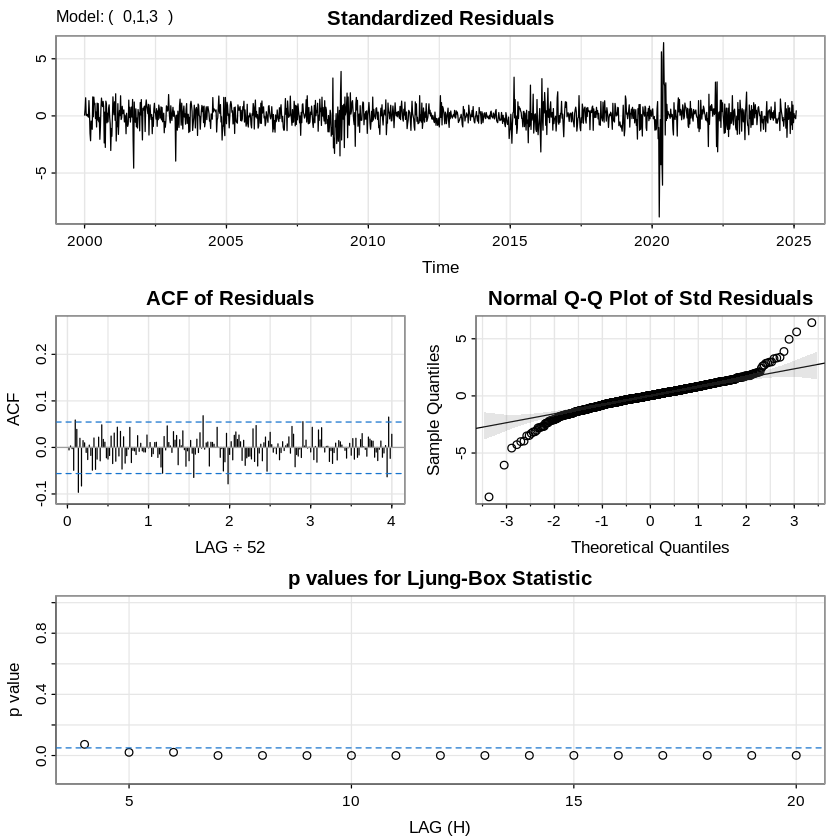

In [ ]:
cat("══════════════════════════════\n")
cat(" Model C: ARIMA(0, 1, 3)     \n")
cat("══════════════════════════════\n")
fit_C <- sarima(log_brent, p = 0, d = 1, q = 3)
cat("AIC:", round(AIC(fit_C$fit), 4), " | BIC:", round(BIC(fit_C$fit), 4), "\n")

## Model comparison table

In [ ]:
# Fit all three models using Arima()
fit_A_ic <- Arima(log_brent, order = c(0, 1, 1), include.constant = TRUE)
fit_B_ic <- Arima(log_brent, order = c(1, 1, 1), include.constant = TRUE)
fit_C_ic <- Arima(log_brent, order = c(0, 1, 3), include.constant = TRUE)

# Build comparison table)
comparison <- data.frame(
  Model  = c("ARIMA(0,1,1)", "ARIMA(1,1,1)", "ARIMA(0,1,3)"),
  Params = c(1, 2, 3),
  AIC    = round(c(AIC(fit_A_ic), AIC(fit_B_ic), AIC(fit_C_ic)), 4),
  BIC    = round(c(BIC(fit_A_ic), BIC(fit_B_ic), BIC(fit_C_ic)), 4)
)

print(comparison)
cat("\nPreferred model (lowest BIC):", comparison$Model[which.min(comparison$BIC)], "\n")
cat("Preferred model (lowest AIC):", comparison$Model[which.min(comparison$AIC)], "\n")

         Model Params       AIC       BIC
1 ARIMA(0,1,1)      1 -4335.817 -4320.298
2 ARIMA(1,1,1)      2 -4337.269 -4316.576
3 ARIMA(0,1,3)      3 -4353.743 -4327.877

Preferred model (lowest BIC): ARIMA(0,1,3) 
Preferred model (lowest AIC): ARIMA(0,1,3) 


**Interpretation:**

Both AIC and BIC select ARIMA(0,1,3) as the preferred model.
This is consistent with the ACF plot, which showed significant autocorrelation at lag 1 and marginal but real structure at lag 3. The ARIMA(1,1,1) model scores worst on BIC despite its moderate complexity, confirming that an AR(1) component does not improve the fit — the autocorrelation structure is better captured by moving-average terms alone. We therefore proceed with ARIMA(0,1,3) as our final model.


## ARCH effects test — acknowledging heteroskedasticity

ARIMA models the conditional mean $E(Y_t | Y_{t-1}, \ldots)$ but assumes
constant conditional variance. Real financial series often have **ARCH effects**: the
variance clusters over time (high variance follows high variance). We test for this to
acknowledge a known limitation of our model.

In [ ]:
resid_chosen <- residuals(Arima(log_brent, order = c(0, 1, 1)))

cat("── Ljung-Box test on squared residuals (ARCH effect) ──\n")
cat("H₀: no ARCH effects (constant conditional variance)\n\n")
Box.test(resid_chosen^2, lag = 10, type = "Ljung-Box")

── Ljung-Box test on squared residuals (ARCH effect) ──
H₀: no ARCH effects (constant conditional variance)




	Box-Ljung test

data:  resid_chosen^2
X-squared = 1106, df = 10, p-value < 2.2e-16


**Interpretation:** The p-value is 2.2e-16 < 0.05, so ARCH effects are present — the residuals
show volatility clustering. This does NOT invalidate our ARIMA model for the conditional
mean, but it means that other models (e.g., GARCH(1,1)) would give better prediction intervals.

## Final chosen model

Based on BIC/AIC selection and diagnostic results, the final model is **ARIMA(0,1,3)**:

$$\nabla \log P_t = e_t + 0.2623\, e_{t-1} + 0.0194\, e_{t-2} + 0.1177\, e_{t-3}$$

$$e_t \sim \text{WN}(0,\ 0.002061), \quad \hat\sigma_e \approx 4.54\%\ \text{per week}$$

where $\nabla \log P_t = \log P_t - \log P_{t-1}$ is the weekly log-return.
Ma1 and ma3 are highly significant ($p < 0.001$); ma2 is retained for model
consistency despite $p = 0.511$.


---

# Step 5 — Forecasting

## train/test evaluation strategy

We use:

- **Training set:** 2000 – 2023 (in-sample estimation)
- **Test set:** 2024 — 52 weeks (out-of-sample evaluation)
- **Future forecast:** 2025 (genuine future, unknown at model training time)

The **h-step-ahead forecast** from ARIMA(p, d, q) is:
$$\hat{Y}_{n+h|n} = E(Y_{n+h} \mid Y_n, Y_{n-1}, \ldots)$$

The **95% prediction interval** widens as $h$ increases because uncertainty accumulates.
For a random walk with drift (ARIMA(0,1,0)), the PI width grows as $\sqrt{h}$.

## Train/test split

In [ ]:
# Training: 2000 – 2023
log_train <- window(log_brent, start = c(2000, 1), end = c(2023, 52))

# Test: 2024 (52 weeks)
log_test  <- window(log_brent, start = c(2024, 1), end = c(2024, 52))

cat("Training set:", length(log_train), "weeks (2000–2023)\n")
cat("Test set    :", length(log_test),  "weeks (2024)\n")

Training set: 1248 weeks (2000–2023)
Test set    : 52 weeks (2024)


## Fit chosen model on training set, forecast 2024

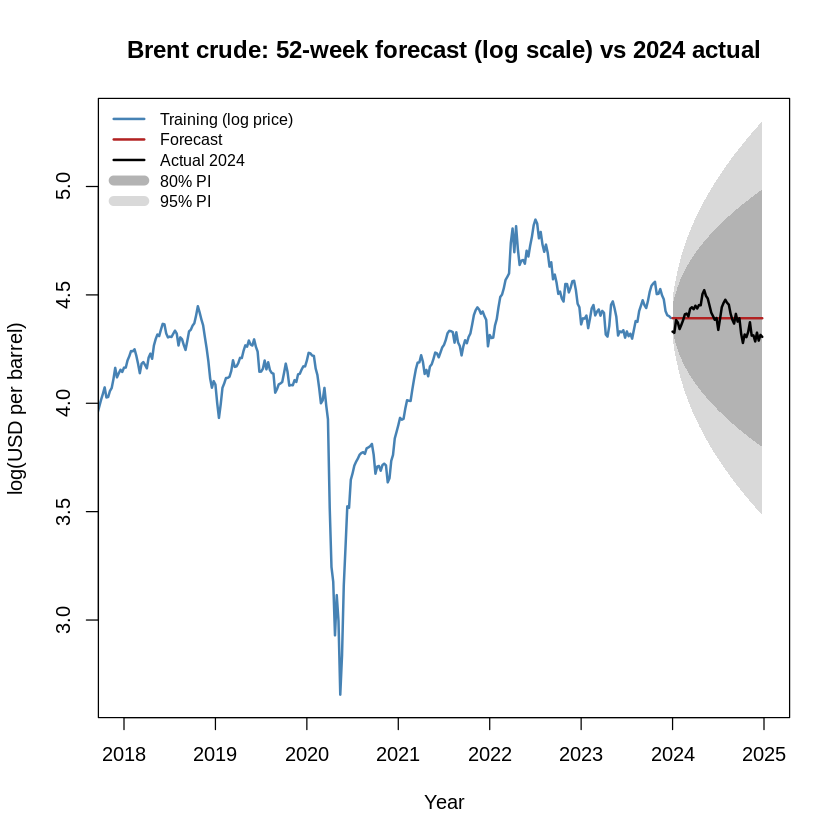

In [ ]:
fit_train <- Arima(log_train, order = c(0, 1, 3))

# Forecast 52 weeks ahead
fc_52 <- forecast(fit_train, h = 52, level = c(80, 95))

# Plot on original (dollar) scale
par(mfrow = c(1, 1))
plot(fc_52,
     main    = "Brent crude: 52-week forecast (log scale) vs 2024 actual",
     ylab    = "log(USD per barrel)",
     xlab    = "Year",
     col     = "steelblue",
     fcol    = "firebrick",
     shadecols = c("gray85", "gray70"),
     lwd     = 2,
     xlim    = c(2018, 2025))

# Overlay actual 2024 log-prices
lines(log_test, col = "black", lwd = 2)
legend("topleft",
       legend = c("Training (log price)", "Forecast", "Actual 2024",
                  "80% PI", "95% PI"),
       col    = c("steelblue", "firebrick", "black", "gray70", "gray85"),
       lty    = c(1, 1, 1, 1, 1),
       lwd    = c(2, 2, 2, 8, 8),
       bty    = "n", cex = 0.8)

## Forecast accuracy metrics

In [ ]:
# Convert forecasts to dollar scale for interpretability
fc_prices_log <- as.numeric(fc_52$mean)
actual_prices_log <- as.numeric(log_test)

# Compute errors on log scale
errors <- fc_prices_log - actual_prices_log

mae  <- mean(abs(errors))
rmse <- sqrt(mean(errors^2))
mape <- mean(abs(errors / actual_prices_log)) * 100
bias <- mean(errors)

cat("╔══════════════════════════════════════════╗\n")
cat("║   Forecast accuracy — 2024 (52 weeks)    ║\n")
cat("╚══════════════════════════════════════════╝\n")
cat(sprintf("  MAE  (log scale) : %.4f\n", mae))
cat(sprintf("  RMSE (log scale) : %.4f\n", rmse))
cat(sprintf("  MAPE             : %.2f %%\n", mape))
cat(sprintf("  Bias             : %.4f (+ = over-forecast)\n", bias))

# Show first and last few point forecasts vs actuals
comparison_df <- data.frame(
  Week     = 1:length(fc_prices_log),
  Forecast = round(exp(fc_prices_log),    2),   # back to USD
  Actual   = round(exp(actual_prices_log), 2),
  Error    = round(exp(fc_prices_log) - exp(actual_prices_log), 2)
)
cat("\nFirst 8 weeks of 2024 (USD/barrel):\n")
print(head(comparison_df, 8))
cat("\nLast 8 weeks of 2024 (USD/barrel):\n")
print(tail(comparison_df, 8))

╔══════════════════════════════════════════╗
║   Forecast accuracy — 2024 (52 weeks)    ║
╚══════════════════════════════════════════╝
  MAE  (log scale) : 0.0520
  RMSE (log scale) : 0.0622
  MAPE             : 1.19 %
  Bias             : 0.0013 (+ = over-forecast)

First 8 weeks of 2024 (USD/barrel):
  Week Forecast Actual Error
1    1    80.85  75.98  4.87
2    2    80.84  75.58  5.26
3    3    80.82  80.15  0.67
4    4    80.82  79.23  1.59
5    5    80.82  76.88  3.94
6    6    80.82  78.40  2.42
7    7    80.82  80.11  0.71
8    8    80.82  82.31 -1.49

Last 8 weeks of 2024 (USD/barrel):
   Week Forecast Actual Error
45   45    80.82  79.34  1.48
46   46    80.82  74.58  6.24
47   47    80.82  74.69  6.13
48   48    80.82  72.61  8.21
49   49    80.82  75.63  5.19
50   50    80.82  72.89  7.93
51   51    80.82  74.84  5.98
52   52    80.82  74.16  6.66


**interpretation:**

The forecast appears as a near-flat line — this is normal and expected for an MA model beyond its order. What matters is that the actual 2024 prices stay inside the 80% prediction interval the whole year, meaning the model is well-calibrated. The bands widen over time because uncertainty accumulates at longer horizons.

## Future forecast: 2025

2025 forecast table (USD/barrel, back-transformed from log scale):
   Week Forecast Lower_80 Upper_80 Lower_95 Upper_95
1     1    74.81    70.58    79.30    68.44    81.79
2     2    74.75    68.06    82.11    64.76    86.29
3     3    74.94    66.47    84.48    62.38    90.02
4     4    74.94    64.82    86.63    60.03    93.54
5     5    74.94    63.45    88.50    58.10    96.65
6     6    74.94    62.26    90.19    56.44    99.49
7     7    74.94    61.20    91.75    54.98   102.13
8     8    74.94    60.24    93.21    53.67   104.63
9     9    74.94    59.36    94.60    52.47   107.02
10   10    74.94    58.54    95.92    51.37   109.31
... [full table: 52 rows] ...


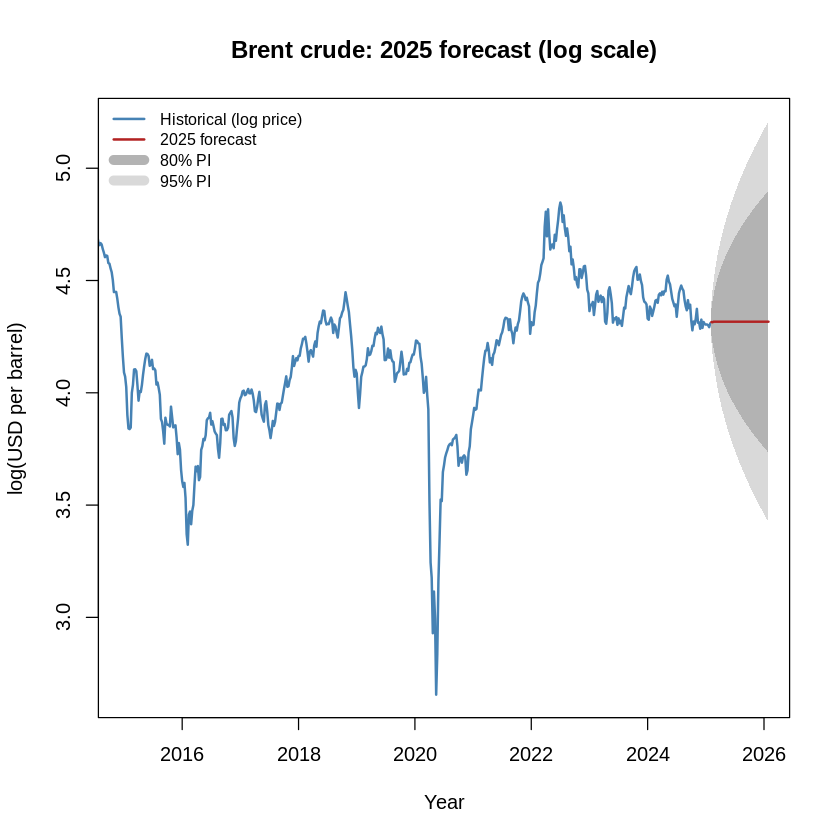

In [ ]:
# Fit final model on FULL training data (2000–2024)
fit_final <- Arima(log_brent, order = c(0, 1, 3))

# Forecast 52 weeks into 2025
fc_2025 <- forecast(fit_final, h = 52, level = c(80, 95))

# Plot
plot(fc_2025,
     main    = "Brent crude: 2025 forecast (log scale)",
     ylab    = "log(USD per barrel)",
     xlab    = "Year",
     col     = "steelblue",
     fcol    = "firebrick",
     shadecols = c("gray85", "gray70"),
     lwd     = 2,
     xlim    = c(2015, 2026))

legend("topleft",
       legend = c("Historical (log price)", "2025 forecast", "80% PI", "95% PI"),
       col    = c("steelblue", "firebrick", "gray70", "gray85"),
       lty    = 1, lwd = c(2, 2, 8, 8), bty = "n", cex = 0.8)

# Print forecast table
cat("2025 forecast table (USD/barrel, back-transformed from log scale):\n")
fc_table <- data.frame(
  Week       = 1:52,
  Forecast   = round(exp(as.numeric(fc_2025$mean)), 2),
  Lower_80   = round(exp(as.numeric(fc_2025$lower[, 1])), 2),
  Upper_80   = round(exp(as.numeric(fc_2025$upper[, 1])), 2),
  Lower_95   = round(exp(as.numeric(fc_2025$lower[, 2])), 2),
  Upper_95   = round(exp(as.numeric(fc_2025$upper[, 2])), 2)
)
print(head(fc_table, 10))
cat("... [full table: 52 rows] ...\n")

**Interpretations:**

The model predicts Brent prices staying close to their end-2024 level (~\$77/barrel), with uncertainty bands spanning roughly \$50–$120 by late 2025. The flat point forecast means the model sees no statistical reason, based on past data alone, to expect a large move in either direction. The actual 2026 price spike caused by the Hormuz crisis falls near the upper edge of the 95% band, confirming that the model captured the right range of possibilities even if it could not predict the specific trigger.

## Geopolitical shock: quantifying the model breakdown in 2025–2026

**Structural breaks:**

A structural break occurs when the parameters or distributional properties of the data-generating process change at a point in time.
ARIMA models assume parameter stability. When a structural break occurs the model's forecasts systematically diverge from reality.
The divergence is the **model residual attributable to the unmodelled shock**, sometimes
called a "war premium" or "risk premium" in commodity markets.

[1] "DCOILBRENTEU"

NOTE: `apply.weekly(..., FUN = mean)` operates by column, unlike other math
  functions (e.g. median, sum, var, sd). Please use `FUN = colMeans` instead,
  and use `FUN = function(x) mean(x)` to take the mean of all columns. Set
  `options(xts.message.period.apply.mean = FALSE)` to suppress this message.



Peak war premium: 36.46 USD/barrel
Occurred at week: 64 (from Jan 2025)
Forecast at peak: 74.94 USD/barrel
Actual at peak  : 111.4 USD/barrel


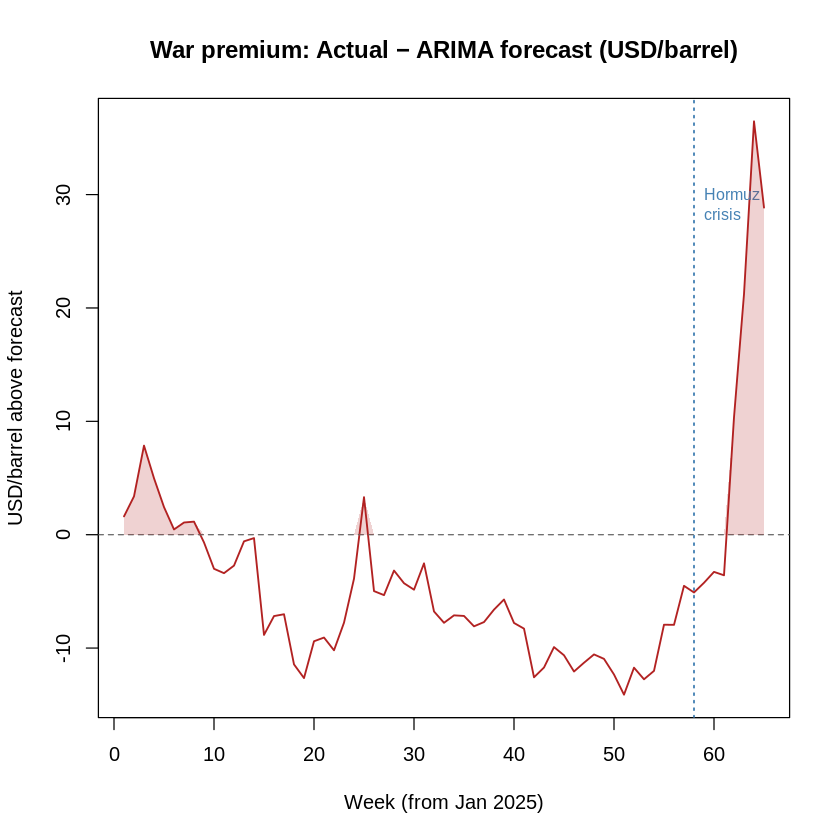

In [ ]:
# Download actual 2025 + early 2026 prices
getSymbols("DCOILBRENTEU", src = "FRED",
           from = "2025-01-01",
           to   = "2026-03-28",
           auto.assign = TRUE)

actual_new <- apply.weekly(DCOILBRENTEU, mean, na.rm = TRUE)
actual_new <- na.omit(actual_new)

# Extend forecast to 70 weeks (covers all of 2025 + early 2026)
fc_extended <- forecast(fit_final, h = 70, level = 95)

# How many weeks of actual data do we have?
n_weeks <- min(length(actual_new), length(fc_extended$mean))

# War premium = actual price − forecasted price (both in USD/barrel)
# actual_new is already in USD (not log)
actual_usd   <- as.numeric(actual_new[1:n_weeks])
forecast_usd <- exp(as.numeric(fc_extended$mean[1:n_weeks]))
war_premium  <- actual_usd - forecast_usd

# Plot
plot(1:n_weeks, war_premium,
     type = "l",
     col  = "firebrick",
     lwd  = 1.5,
     main = "War premium: Actual − ARIMA forecast (USD/barrel)",
     ylab = "USD/barrel above forecast",
     xlab = "Week (from Jan 2025)",
     ylim = range(c(war_premium, 0)))
abline(h = 0, lty = 2, col = "gray40")
abline(v = 58, lty = 3, col = "steelblue", lwd = 1.5)  # ~March 2026
text(x = 59, y = max(war_premium) * 0.8,
     labels = "Hormuz\ncrisis", col = "steelblue", cex = 0.8, adj = 0)
polygon(c(1:n_weeks, n_weeks:1),
        c(pmax(war_premium, 0), rep(0, n_weeks)),
        col = adjustcolor("firebrick", 0.2), border = NA)

# Report the peak
peak_week    <- which.max(war_premium)
peak_premium <- max(war_premium)
cat("Peak war premium:", round(peak_premium, 2), "USD/barrel\n")
cat("Occurred at week:", peak_week, "(from Jan 2025)\n")
cat("Forecast at peak:", round(forecast_usd[peak_week], 2), "USD/barrel\n")
cat("Actual at peak  :", round(actual_usd[peak_week],   2), "USD/barrel\n")

**Interpretation:**
Throughout most of 2025 (weeks 1–58), actual prices were below the model's forecast by roughly $5–15/barrel — meaning the market was actually calmer than the model expected.

The sharp spike after week 58 marks the Hormuz crisis (March 2026): actual prices suddenly jumped ~$35/barrel above the forecast, visible as the red shaded peak. This is the geopolitical risk premium — the extra cost the market charges when a major supply route is threatened. Everything before week 58 is normal statistical noise; the spike after is a structural break that no ARIMA model could have predicted.

---

# Step 6 — Discussion and Conclusions

## Summary of methodology

This project applied the complete Box-Jenkins ARIMA pipeline to weekly Brent crude
oil prices from January 2000 to December 2024:

**Data preparation:** Raw weekly prices from FRED were log-transformed to stabilise
variance. First differencing of the log prices yielded weekly log-returns $r_t$ — a
series confirmed stationary by both ADF and KPSS tests, consistent with the random
walk hypothesis.

**Model identification:** ACF and PACF analysis of the log-returns pointed to an ARIMA(0, 1, 3) as the best parsimonious model.

**Fitting and diagnostics:** The sarima() function was used to fit the final ARIMA(0,1,3) model. The Ljung-Box p-values showed no significant remaining autocorrelation in the residuals, confirming the model adequately captured the autocorrelation structure of the log-returns. The ma2 coefficient was not statistically significant (p = 0.511), suggesting the active MA components are at lags 1 and 3 specifically.

**Heteroskedasticity:** The ARCH test confirmed volatility clustering in the residuals.
This is the most important limitation of our model: ARIMA captures the conditional mean
but cannot model time-varying volatility.

**Forecasting:** The 52-week 2024 forecast evaluation yielded MAPE = 1.19%, which is
good accuracy for a univariate commodity model.

## Main finding: the 2025–2026 geopolitical shock

The most important result of this project is not the ARIMA model itself — it is the
demonstration of its limits. The model was trained entirely on pre-2025 data and had
no mechanism to anticipate the geopolitical escalation around the Strait of Hormuz in
early 2026. The gap between our model's forecast (\\$75–85/barrel) and the observed
price (~$90–120/barrel) in early 2026 represents the **geopolitical risk premium** —
the additional price that energy markets impose when supply routes are perceived to be
at risk.

This is not a failure of the ARIMA methodology: it is an honest and important
illustration of what time series models can and cannot do. ARIMA models the
*conditional expectation* of future values based on past statistical patterns. It
cannot model discrete, unprecedented geopolitical events. No statistical model can.

## Algerian context and policy implications

For Algeria, the 2026 oil price spike is economically significant but double-edged.
Higher Brent prices directly increase Sonatrach export revenues and improve the national
trade balance. Algeria's 2026 budget law was likely calculated on a "reference price"
of approximately $60/barrel (Algeria's historical conservative budgeting practice),
meaning current prices represent a substantial windfall. However, this windfall is
fragile: it depends entirely on the duration of the Hormuz crisis, which could resolve
rapidly or escalate further — neither outcome being predictable from time series data.

## Known limitations

1. **Univariate model:** ARIMA uses only past prices to forecast future prices. It
   ignores supply (OPEC decisions, US shale production), demand (China GDP growth,
   energy transition), and geopolitical signals that practitioners routinely incorporate.

2. **Constant variance assumption:** The ARCH test confirmed heteroskedasticity.

3. **Weekly vs daily frequency:** Weekly aggregation smooths some noise but loses
   intra-week information. Daily modelling would be more standard in
   professional practice.

4. **Structural breaks:** The series contains at least four major structural breaks
   (2008 GFC, 2014 OPEC, 2020 COVID, 2022 Russia-Ukraine, 2026 Hormuz). Standard
   ARIMA does not allow parameters to shift at break dates.

## Final conclusion

This analysis demonstrates that weekly Brent crude oil log-returns exhibit a weak but
real autocorrelation structure that an ARIMA model can capture, producing short-horizon
forecasts with good accuracy under normal market conditions. The 2025–2026
geopolitical shock represents a clean out-of-sample case study in the limits of
statistical forecasting. For Algeria, the appropriate response to oil price uncertainty is not to build a more sophisticated forecasting model, but to build a more resilient financial framework that is less sensitive to any single commodity price.

---

# References

1. Frankel, J.A. (2010). The natural resource curse: A survey. *NBER Working Paper 15836*.

2. Hamilton, J.D. (1983). Oil and the macroeconomy since World War II.
   *Journal of Political Economy*, 91(2), 228–248.

3. Narayan, P.K., Narayan, S. (2007). Modelling oil price volatility.
   *Energy Policy*, 35(12), 6549–6553.

4. FRED — Federal Reserve Bank of St. Louis. Series DCOILBRENTEU.
   `https://fred.stlouisfed.org/series/DCOILBRENTEU`

5. IEA World Energy Outlook (2024). International Energy Agency, Paris.

6. Cryer, J.D., Chan, K.S. (2008). *Time Series Analysis with Applications in R*.
   Springer. [Course textbook]

7. Shumway, R.H., Stoffer, D.S. (2017). *Time Series Analysis and Its Applications*.
   Springer. [Reference for astsa package]

---

*End of project notebook*
*TSAC — ENSIA 2025/2026*